# 03b · One-time holdout (Apr–Jun 2026) and the final model

Selection was frozen in `03_modeling.ipynb` (config in `kestrel.train.FINAL_CONFIG`). This notebook:
1. trains that exact configuration on **Apr 2025 – Mar 2026** with the out-of-fold sigmoid calibrator, and scores **Apr–Jun 2026 once**;
2. turns walk-forward + holdout results into the expected-score ranges;
3. retrains on **all 15 months** with the same calibrator and saves `models/model.joblib` + `models/model_meta.json`.

Nothing here feeds back into any modelling choice.

In [1]:
from datetime import datetime
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from kestrel.config import FIGURES_DIR, MODELS_DIR
from kestrel.train import (FINAL_CONFIG, FOLD_NAMES, SELECTION_END, load_training_frame, train_final,
                           ranking_metrics, save)

EXPECTED = {"kind": "lr", "params": {}, "monotonic": False, "half_life": None, "calibration_folds": [0, 1, 2],
            "features": ["promised_delivery_days", "customer_prior_returns", "customer_prior_orders", "prior_return_rate",
                         "has_prior_return", "discount_pct", "shield", "payment_mode", "family"]}
assert FINAL_CONFIG == EXPECTED, "config differs from the one frozen in 03_modeling"
X, y, ts, catalogue, pack = load_training_frame()
hold = (ts >= SELECTION_END).to_numpy()
print(f"holdout scored at {datetime.now():%Y-%m-%d %H:%M} | Apr-Jun 2026: {hold.sum()} orders, {y[hold].sum()} returns ({y[hold].mean():.4f})")

holdout scored at 2026-10-06 12:34 | Apr-Jun 2026: 2126 orders, 245 returns (0.1152)


## 1 · Score Apr–Jun 2026 once

In [2]:
model_h, oof = train_final(FINAL_CONFIG, X, y, ts, catalogue, end=SELECTION_END)
p_hold = model_h.predict_proba(X[hold])
raw_hold = model_h.raw_proba(X[hold])
hm = ranking_metrics(y[hold], p_hold)
print(f"calibrator a={model_h.calibrator.a:.3f} b={model_h.calibrator.b:.3f} | AUC raw {roc_auc_score(y[hold], raw_hold):.4f} = calibrated {hm['roc_auc']:.4f}")
print(f"accuracy at 0.5: {((p_hold > 0.5) == y[hold]).mean():.4f} | 'nobody returns' accuracy: {1 - y[hold].mean():.4f}  (accuracy is not the metric)")
pd.Series(hm).to_frame("Apr-Jun 2026 (holdout, once)")

calibrator a=0.986 b=-0.068 | AUC raw 0.7872 = calibrated 0.7872
accuracy at 0.5: 0.8942 | 'nobody returns' accuracy: 0.8848  (accuracy is not the metric)


,"Apr-Jun 2026 (holdout, once)"
roc_auc,0.7872
pr_auc,0.4210
brier,0.0843
base_rate,0.1152
orders,2126.0000
precision_top5,0.5755
recall_top5,0.2490
precision_top10,0.4366
recall_top10,0.3796
precision_top20,0.3318


In [3]:
wf = oof.groupby("fold").apply(lambda g: pd.Series(ranking_metrics(g.y, model_h.calibrator.transform(g.raw))), include_groups=False)
wf.index = [FOLD_NAMES[i] for i in wf.index]
summary = pd.concat([wf, pd.DataFrame(hm, index=["Apr-Jun 26 (holdout)"])])
summary[["orders", "base_rate", "roc_auc", "pr_auc", "brier", "precision_top5", "recall_top5", "precision_top10", "recall_top10", "precision_top20", "recall_top20"]].round(3)

,orders,base_rate,roc_auc,pr_auc,brier,precision_top5,recall_top5,precision_top10,recall_top10,precision_top20,recall_top20
Jul-Sep 25,2157.0,0.111,0.800,0.419,0.080,0.583,0.264,0.458,0.414,0.313,0.565
Oct-Dec 25,2082.0,0.108,0.770,0.344,0.084,0.423,0.196,0.370,0.342,0.303,0.560
Jan-Mar 26,2126.0,0.116,0.766,0.376,0.088,0.538,0.231,0.404,0.348,0.311,0.534
Apr-Jun 26 (holdout),2126.0,0.115,0.787,0.421,0.084,0.576,0.249,0.437,0.380,0.332,0.576


mean predicted 0.1103 vs actual 0.1152


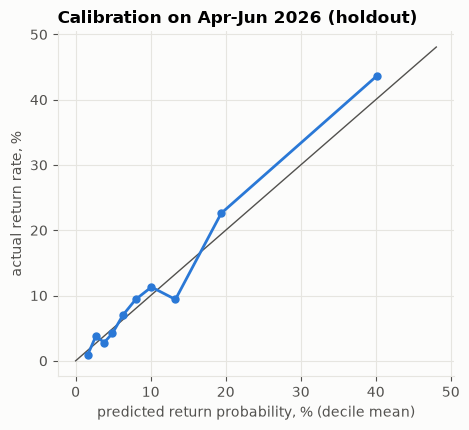

,predicted,actual,orders
decile,,,
0,0.016,0.009,213
1,0.027,0.038,213
2,0.038,0.028,212
3,0.049,0.042,213
4,0.063,0.070,213
5,0.080,0.094,212
6,0.101,0.113,212
7,0.133,0.094,213
8,0.194,0.226,212


In [4]:
d = pd.DataFrame({"p": p_hold, "y": y[hold]})
d["decile"] = pd.qcut(d.p, 10, labels=False, duplicates="drop")
rel = d.groupby("decile").agg(predicted=("p", "mean"), actual=("y", "mean"), orders=("y", "size")).round(3)
print(f"mean predicted {d.p.mean():.4f} vs actual {d.y.mean():.4f}")
BLUE, INK2, GRID, SURFACE = "#2a78d6", "#52514e", "#e6e5e0", "#fcfcfb"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE, "axes.edgecolor": GRID,
                     "axes.grid": True, "grid.color": GRID, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2})
fig, ax = plt.subplots(figsize=(4.8, 4.4))
lim = max(rel.predicted.max(), rel.actual.max()) * 100 * 1.1
ax.plot([0, lim], [0, lim], color=INK2, lw=1)
ax.plot(rel.predicted * 100, rel.actual * 100, color=BLUE, lw=2, marker="o", ms=5)
ax.set_xlabel("predicted return probability, % (decile mean)"); ax.set_ylabel("actual return rate, %")
ax.set_title("Calibration on Apr-Jun 2026 (holdout)", loc="left")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "03b_calibration_holdout.png", dpi=150); plt.show()
rel

## 2 · Expected score on the test quarter (Jul–Sep 2026)

In [5]:
aucs = list(summary.roc_auc); prs = list(summary.pr_auc); rates = list(summary.base_rate)
print("ROC-AUC across 3 walk-forward folds + holdout:", np.round(aucs, 3), "-> min/mean/max", round(min(aucs), 3), round(np.mean(aucs), 3), round(max(aucs), 3))
print("PR-AUC:", np.round(prs, 3), "at base rates", np.round(rates, 3))
print("PR-AUC / base rate (lift):", np.round(np.array(prs) / np.array(rates), 2))

ROC-AUC across 3 walk-forward folds + holdout: [0.8   0.77  0.766 0.787] -> min/mean/max 0.766 0.781 0.8
PR-AUC: [0.419 0.344 0.376 0.421] at base rates [0.111 0.108 0.116 0.115]
PR-AUC / base rate (lift): [3.78 3.18 3.24 3.65]


## 3 · Final model: all 15 months, same configuration and calibrator

In [6]:
model, oof_final = train_final(FINAL_CONFIG, X, y, ts, catalogue, end=None)
assert np.allclose([model.calibrator.a, model.calibrator.b], [model_h.calibrator.a, model_h.calibrator.b])
pre, lr = model.pipeline.named_steps["pre"], model.pipeline.named_steps["model"]
coef = pd.DataFrame({"feature": pre.get_feature_names_out(), "coefficient": lr.coef_[0]})
coef["odds_ratio"] = np.exp(coef.coefficient)
num_sd = dict(zip(pre.transformers_[0][2], pre.named_transformers_["num"].scale_))
coef["per"] = coef.feature.map(lambda f: f"+1 SD ({num_sd[f.split('__')[1]]:.2f})" if f.startswith("num__") else "vs. average category")
print("intercept", round(float(lr.intercept_[0]), 3))
coef.sort_values("coefficient", ascending=False).round(3)

intercept -1.811


,feature,coefficient,odds_ratio,per
1,num__customer_prior_returns,0.559,1.748,+1 SD (0.55)
15,cat__family_Robot Vacuum,0.535,1.708,vs. average category
0,num__promised_delivery_days,0.438,1.549,+1 SD (1.92)
6,num__shield,0.394,1.483,+1 SD (0.42)
7,cat__payment_mode_cod,0.344,1.411,vs. average category
5,num__discount_pct,0.244,1.276,+1 SD (7.12)
17,cat__family_Water Purifier,0.167,1.182,vs. average category
4,num__has_prior_return,0.144,1.155,+1 SD (0.34)
2,num__customer_prior_orders,-0.002,0.998,+1 SD (1.27)
16,cat__family_Room Heater,-0.086,0.918,vs. average category


**Note on the history coefficients:** the negative coefficient on prior return rate (and the near-zero one on prior orders) is **collinearity among the four customer-history features** (prior returns, prior orders, prior return rate, has-prior-return all move together), not an error: once prior returns and has-prior-return are in, the rate only adjusts their combined effect. Individually these coefficients are not interpretable, so the service **sums the four contributions into one "customer history" reason**. *(Markdown added after the one-time run; no cell was re-executed.)*

In [7]:
metrics = {
    "walk_forward": {k: {m: float(v) for m, v in row.items()} for k, row in wf.round(4).to_dict("index").items()},
    "holdout_apr_jun_2026": hm,
    "expected_test": {"roc_auc_range": [round(min(aucs), 3), round(max(aucs), 3)], "pr_auc_range": [round(min(prs), 3), round(max(prs), 3)]},
}
meta = save(model, catalogue, dict(FINAL_CONFIG, training_window="2025-04-01 to 2026-06-30"), metrics)
print("saved:", sorted(p.name for p in MODELS_DIR.iterdir()))
print({k: meta[k] for k in ("model_version", "kind", "features", "calibrator", "unknown_value_weights")})

saved: ['model.joblib', 'model_meta.json']
{'model_version': '2026-10-06', 'kind': 'lr', 'features': ['promised_delivery_days', 'customer_prior_returns', 'customer_prior_orders', 'prior_return_rate', 'has_prior_return', 'discount_pct', 'shield', 'payment_mode', 'family'], 'calibrator': {'a': 0.9857221421902737, 'b': -0.06792476127104964, 'fitted_on_folds': ['Jul-Sep 25', 'Oct-Dec 25', 'Jan-Mar 26']}, 'unknown_value_weights': {'shield': {0.0: 0.7784653465346535, 1.0: 0.22153465346534654}, 'payment_mode': {'prepaid_upi': 0.3732863670982483, 'cod': 0.3000761614623001, 'prepaid_card': 0.20496953541507998, 'emi': 0.12166793602437166}, 'family': {'Robot Vacuum': 0.14794364051789793, 'Ceiling Fan': 0.14575399847677076, 'Room Heater': 0.14518278750952018, 'Air Fryer': 0.14432597105864434, 'Induction Cooktop': 0.14051789794364053, 'Mixer Grinder': 0.13813785224676314, 'Water Purifier': 0.13813785224676314}}}
